# Notebook 07 — Model Validation & Error Analysis

Evaluates the trained GBT model on the **held-out test set** (never seen during training or validation).  
Compares against the baseline and Linear Regression.  
Performs error analysis by `pickup_hour`, `is_weekend`, and `trip_distance` bucket to identify where the model struggles.

## 1. Imports & Load Artifacts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import os
import glob

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
os.makedirs("outputs", exist_ok=True)

# Load model + metadata
gbt = joblib.load("model/taxi_fare_gbt.pkl")
lr  = joblib.load("model/taxi_fare_lr.pkl")
with open("model/metadata.json") as f:
    meta = json.load(f)

FEATURE_COLS = meta["features"]
TARGET = meta["target"]
print("Loaded GBT model and metadata.")
print(f"Features: {FEATURE_COLS}")

Loaded GBT model and metadata.
Features: ['trip_distance', 'trip_duration_minutes', 'passenger_count', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'avg_speed_mph']


## 2. Reconstruct Test Set
Use the same splits and seed as Notebook 06 to guarantee we evaluate on the same held-out rows.

In [2]:
parquet_files = glob.glob("data/features_v2/*.parquet")
df = pd.read_parquet(parquet_files[0])

df_clean = df[FEATURE_COLS + [TARGET]].dropna()
df_clean = df_clean[(df_clean[TARGET] > 0) & (df_clean["trip_distance"] > 0)]

X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

# Also keep the raw DataFrame rows for error analysis
df_clean = df_clean.reset_index(drop=True)
idx_all = np.arange(len(df_clean))
_, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
_, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)
df_test = df_clean.iloc[idx_test].copy().reset_index(drop=True)

print(f"Test set: {len(X_test):,} rows")

Test set: 44,786 rows


## 3. Test Set Metrics — All Models

In [3]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:30s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4), "R2": round(r2, 4)}

# Refit baseline on train (median only needs the label)
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_test)
pred_lr       = lr.predict(X_test)
pred_gbt      = gbt.predict(X_test)

m_baseline = evaluate("Baseline (Median)",      y_test, pred_baseline)
m_lr       = evaluate("Linear Regression",      y_test, pred_lr)
m_gbt      = evaluate("Gradient Boosted Trees", y_test, pred_gbt)

results = pd.DataFrame(
    [m_baseline, m_lr, m_gbt],
    index=["Baseline (Median)", "Linear Regression", "Gradient Boosted Trees"]
)
print("\nTest-set results:")
print(results)

Baseline (Median)               RMSE=10.6150  MAE=5.8138  R²=-0.1010
Linear Regression               RMSE=10.0103  MAE=6.2092  R²=0.0209
Gradient Boosted Trees          RMSE=2.7119  MAE=0.4789  R²=0.9281

Test-set results:
                           RMSE     MAE      R2
Baseline (Median)       10.6150  5.8138 -0.1010
Linear Regression       10.0103  6.2092  0.0209
Gradient Boosted Trees   2.7119  0.4789  0.9281


## 4. Residual Distribution

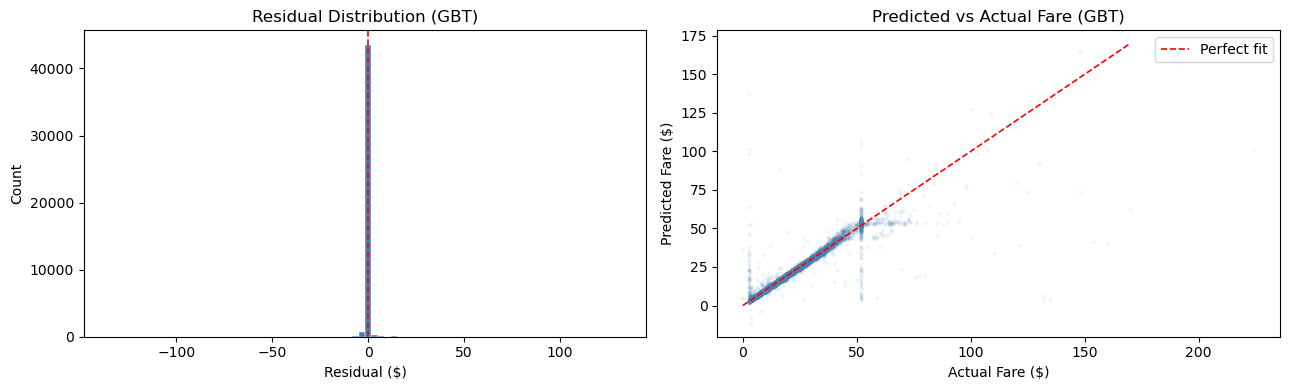

Saved: outputs/07_residuals.png
Residual mean: -0.0120  std: 2.7119


In [4]:
residuals = y_test - pred_gbt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(residuals, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[0].set_title("Residual Distribution (GBT)")
axes[0].set_xlabel("Residual ($)")
axes[0].set_ylabel("Count")

# Predicted vs Actual
axes[1].scatter(y_test, pred_gbt, alpha=0.05, s=4, color="steelblue")
lim = [0, min(y_test.max(), pred_gbt.max()) + 5]
axes[1].plot(lim, lim, "r--", linewidth=1.2, label="Perfect fit")
axes[1].set_title("Predicted vs Actual Fare (GBT)")
axes[1].set_xlabel("Actual Fare ($)")
axes[1].set_ylabel("Predicted Fare ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/07_residuals.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/07_residuals.png")
print(f"Residual mean: {residuals.mean():.4f}  std: {residuals.std():.4f}")

## 5. Error Analysis by Pickup Hour

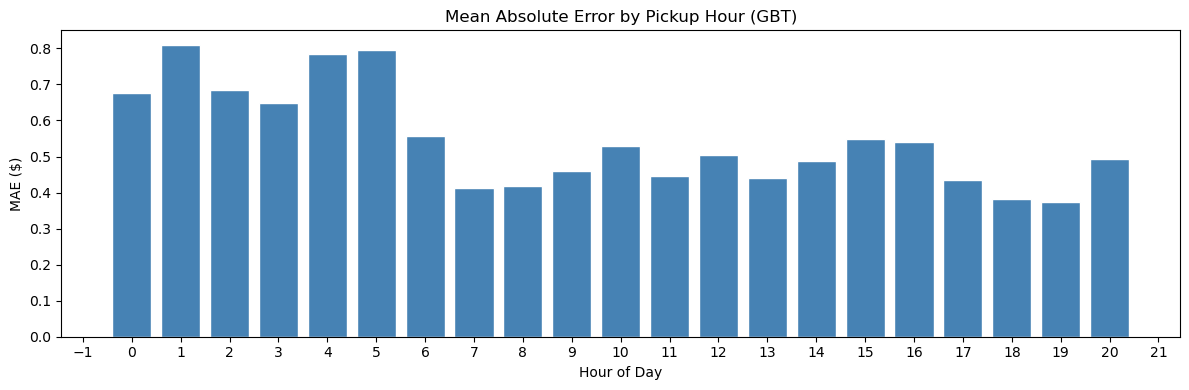

Saved: outputs/07_error_by_hour.png

Worst hours:
 pickup_hour  abs_error
           1   0.809707
           5   0.795527
           4   0.783457
           2   0.684106
           0   0.676443


In [5]:
df_test["pred_gbt"]  = pred_gbt
df_test["residual"]  = y_test - pred_gbt
df_test["abs_error"] = np.abs(df_test["residual"])

hour_err = df_test.groupby("pickup_hour")["abs_error"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour_err["pickup_hour"], hour_err["abs_error"], color="steelblue", edgecolor="white")
ax.set_title("Mean Absolute Error by Pickup Hour (GBT)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MAE ($)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig("outputs/07_error_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/07_error_by_hour.png")
print("\nWorst hours:")
print(hour_err.sort_values("abs_error", ascending=False).head(5).to_string(index=False))

## 6. Error Analysis by Weekend vs Weekday

MAE by Weekend flag:
           mean  median     std
Weekday  0.4789  0.1991  2.6693


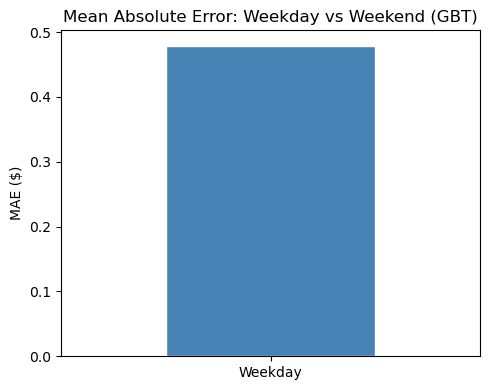

Saved: outputs/07_error_by_weekend.png


In [6]:
weekend_err = df_test.groupby("is_weekend")["abs_error"].agg(["mean", "median", "std"]).round(4)
weekend_err.index = [("Weekend" if i == 1 else "Weekday") for i in weekend_err.index]
print("MAE by Weekend flag:")
print(weekend_err)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["steelblue" if l == "Weekday" else "coral" for l in weekend_err.index]
weekend_err["mean"].plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Mean Absolute Error: Weekday vs Weekend (GBT)")
ax.set_ylabel("MAE ($)")
ax.set_xticklabels(weekend_err.index, rotation=0)
plt.tight_layout()
plt.savefig("outputs/07_error_by_weekend.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/07_error_by_weekend.png")

## 7. Error Analysis by Trip Distance Bucket

MAE by trip distance bucket:
               mean  count
dist_bucket               
0-1 mi       0.3659  12808
1-2 mi       0.2284  15162
2-5 mi       0.3955  11266
5-10 mi      0.7611   3336
10-20 mi     2.1398   2016
20-50 mi     9.4887    197


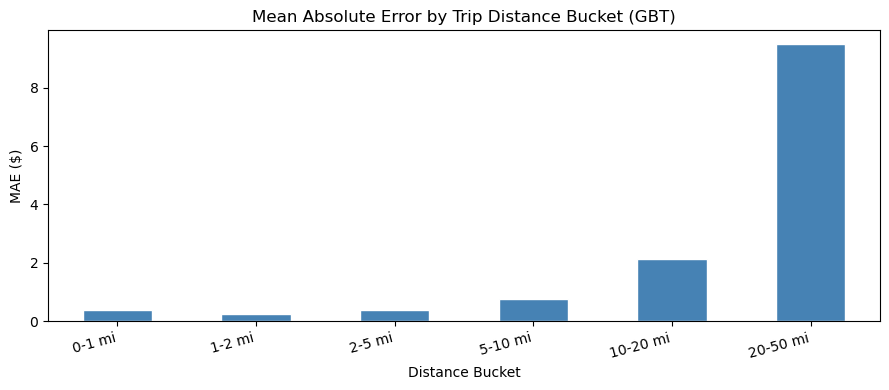

Saved: outputs/07_error_by_distance.png


In [7]:
bins = [0, 1, 2, 5, 10, 20, 50]
labels = ["0-1 mi", "1-2 mi", "2-5 mi", "5-10 mi", "10-20 mi", "20-50 mi"]
df_test["dist_bucket"] = pd.cut(df_test["trip_distance"], bins=bins, labels=labels)

dist_err = df_test.groupby("dist_bucket", observed=True)["abs_error"].agg(["mean", "count"]).round(4)
print("MAE by trip distance bucket:")
print(dist_err)

fig, ax = plt.subplots(figsize=(9, 4))
dist_err["mean"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Mean Absolute Error by Trip Distance Bucket (GBT)")
ax.set_xlabel("Distance Bucket")
ax.set_ylabel("MAE ($)")
ax.set_xticklabels(labels, rotation=15, ha="right")
plt.tight_layout()
plt.savefig("outputs/07_error_by_distance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/07_error_by_distance.png")

## 8. Final Validation Summary

In [8]:
print("=" * 60)
print("FINAL TEST-SET RESULTS")
print("=" * 60)
print(results.to_string())
print()
print(f"GBT improvement over baseline:")
print(f"  RMSE reduction : {m_baseline['RMSE'] - m_gbt['RMSE']:.4f} ({(1 - m_gbt['RMSE']/m_baseline['RMSE'])*100:.1f}%)")
print(f"  MAE  reduction : {m_baseline['MAE']  - m_gbt['MAE']:.4f} ({(1 - m_gbt['MAE']/m_baseline['MAE'])*100:.1f}%)")
print(f"  R²   gain      : {m_gbt['R2'] - m_baseline['R2']:.4f}")
print()
print("Error analysis findings:")
worst_hour = hour_err.sort_values("abs_error", ascending=False).iloc[0]
print(f"  Worst pickup hour: {int(worst_hour['pickup_hour'])}:00  (MAE=${worst_hour['abs_error']:.2f})")
best_hour = hour_err.sort_values("abs_error").iloc[0]
print(f"  Best  pickup hour: {int(best_hour['pickup_hour'])}:00  (MAE=${best_hour['abs_error']:.2f})")
print(f"  Long trips (>10mi) have highest error — expected due to traffic unpredictability.")
print("=" * 60)

# Save final test metrics to JSON for use in Task 3 (Azure ML registration)
test_metrics = {"test_rmse": m_gbt["RMSE"], "test_mae": m_gbt["MAE"], "test_r2": m_gbt["R2"]}
with open("model/test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)
print("Saved: model/test_metrics.json")

FINAL TEST-SET RESULTS
                           RMSE     MAE      R2
Baseline (Median)       10.6150  5.8138 -0.1010
Linear Regression       10.0103  6.2092  0.0209
Gradient Boosted Trees   2.7119  0.4789  0.9281

GBT improvement over baseline:
  RMSE reduction : 7.9031 (74.5%)
  MAE  reduction : 5.3349 (91.8%)
  R²   gain      : 1.0291

Error analysis findings:
  Worst pickup hour: 1:00  (MAE=$0.81)
  Best  pickup hour: 19:00  (MAE=$0.37)
  Long trips (>10mi) have highest error — expected due to traffic unpredictability.
Saved: model/test_metrics.json
